## Satistical Analysis Project

#### Name: Sayed Saidoo

#### Dataset: Students Performance in Exams

#### Project Overview:

This project analyzes the `Students Performance in Exams` dataset to investigate factors associated with student academic achievement. Using descriptive statistics, data visualization, and inferential statistical methods, the analysis explores patterns in mathematics performance among 1,000 students.

The study focuses on one primary research question:

*Do mathematics scores differ significantly across levels of parental education?*

This question will be investigated using a one-way ANOVA, which compares mean mathematics scores across six parental education groups.

The overall goal is to identify meaningful relationships within the data while acknowledging the inherent limitations and follow industry best practices.

### Setup Core Dependencies and Data Ingestion

In [ ]:
# Load core dependecies for statistical anlysis

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.
import statsmodels.api as sm

print("Environment Ready")

Environment Ready


In [59]:
df_exams = pd.read_csv("StudentsPerformance.csv")

### Data Inspection and Cleaning

In [60]:
df_exams.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


- The dataset loaded successfully. The first five rows display student demographic information and academic performance measures, including mathematics, reading, and writing scores.

In [61]:
df_exams.shape

(1000, 8)

In [62]:
df_exams.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


##### Dataset Inspection and Cleaning Summary

The Students Performance dataset was successfully loaded and inspected. The dataset contains 1,000 rows/observations and 8 features, including both categorical and numerical data. All columns loaded with appropriate data types, and no missing values were identified. The dataset meets the required standard for descriptive and inferential statistical analysis without major cleaning steps.

### Descriptive Statistics

In [63]:
# Summary Statistics for numerical variables
df_exams.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


##### Numerical Summary

The dataset contains 1,000 observations for mathematics, reading, and writing scores. Average scores range from approximately 66 to 69 points, indicating similar overall performance across subjects.

The standard deviations are relatively consistent across all three subjects (approximately 15 points), suggesting a moderate level of variability in student achievement. This indicates that while many students perform near the average, there is still substantial variation in academic outcomes across the sample.

The minimum and maximum values demonstrate a wide performance range, with some students achieving very low scores and others attaining perfect scores. The similarity between the mean and median scores suggests that the distributions may be reasonably symmetric, although visualization is required to assess this more formally.

In [64]:
# Summary Statistics for categorical variables
df_exams.describe(include="str")

,gender,race/ethnicity,parental level of education,lunch,test preparation course
count,1000,1000,1000,1000,1000
unique,2,5,6,2,2
top,female,group C,some college,standard,none
freq,518,319,226,645,642


##### Categorical Summary

The dataset contains several categorical variables describing student demographic and educational characteristics. Gender is relatively balanced, with females representing the most common category (518 observations). The largest race/ethnicity group is Group C, comprising 319 students.

Parental education contains six unique categories, making it well suited for a one-way ANOVA analysis to investigate whether mathematics performance differs across educational backgrounds. The most common parental education category is "some college" (226 observations), suggesting adequate representation but further investigation is required.

Overall, the categorical variables exhibit sufficient diversity and representation across groups to support the planned inferential analyses.

In [65]:
# categorical feature frequencies
df_exams["parental level of education"].value_counts()

parental level of education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64

##### Category Frequencies

The parental education variable contains six educational categories, with "some college" (226 observations) and "associate's degree" (222 observations) representing the largest groups. Although the groups are not perfectly balanced, each category contains a sufficient number of observations to support a one-way ANOVA investigating differences in mathematics performance across parental education levels. Reinforcing our previous observation.

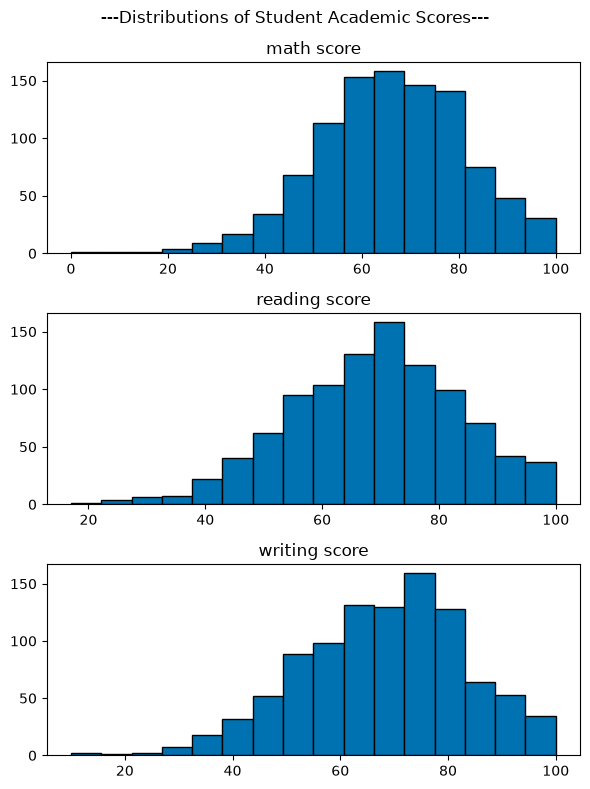

In [66]:
# key numerical feature distributions
numeric_columns = ["math score", "reading score","writing score"]

df_exams[numeric_columns].hist(
    figsize=(6, 8),
    bins=16,
    edgecolor="black",
    layout=(3,1),
    grid=False,
    color="#0072B2"
)

plt.suptitle("---Distributions of Student Academic Scores---")
plt.tight_layout()
plt.show()

##### Distribution of Academic Scores

Visual inspection of the mathematics, reading, and writing score distributions indicates that all three variables are unimodal and concentrated within a relatively similar range. The distributions appear approximately symmetric overall, although a (left) skew is present, reflecting a small number of lower-performing students relative to the majority of scores clustered around the center of the distribution.

These observations are consistent with the descriptive statistics, where the mean and median values for each subject were very similar. The absence of strong multimodality or extreme skewness point us to the possiblity of running a test such as ANOVA.

##### Descriptive Statistics Summary

The exploratory analysis indicates that student performance in mathematics, reading, and writing is relatively consistent across subjects, with average scores ranging from approximately 66 to 69 points. The score distributions appear unimodal and moderately variable, suggesting a diverse range of academic achievement within the sample while maintaining similar overall patterns across subjects.

The categorical variables provide meaningful groupings for further investigation. In particular, parental education contains six distinct categories suitable for comparing mean mathematics performance.

Overall, the descriptive statistics suggest that the dataset is well-structured for inferential analysis and supports the planned use of ANOVA hypothesis testing.

### Visualizations and Further Investigations

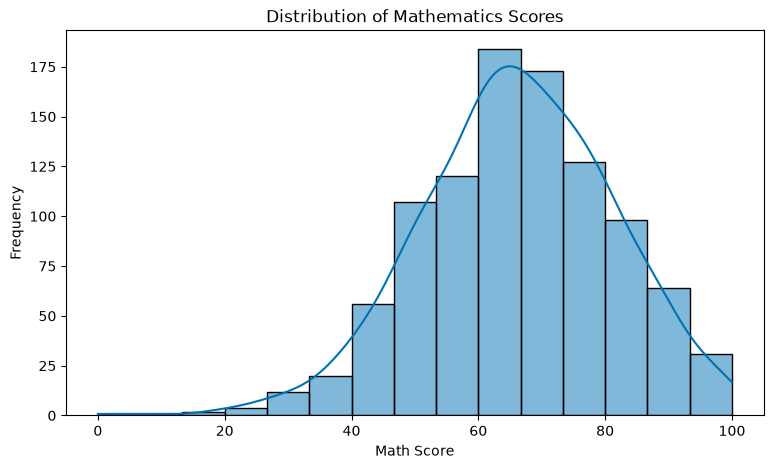

In [67]:
# Histogram of just Math scores (relevant to our hypothesis test)

plt.figure(figsize=(9, 5))

sns.histplot(
    data=df_exams,
    x="math score",
    bins=15,
    kde=True,
    color="#0072B2"
)

plt.title("Distribution of Mathematics Scores")
plt.xlabel("Math Score")
plt.ylabel("Frequency")

plt.show()

#### Distribution of Math Scores with KDE

The histogram shows the overall distribution of mathematics scores across all students in the dataset. Visual inspection indicates a unimodal (reasonably bell shaped) distribution with a left skew. Few students did achieve scores close to zero, while rare, this is plausible in this context and we will not assume data quality issues.

No evidence of multimodality is apparent, suggesting that mathematics performance is not divided into distinct subpopulations. While lower scores are observed, the majority of students are concentrated around the center of the distribution on the higher side (right side).

These findings provide preliminary support for the use of ANOVA, although additional assumption checks related to skewness, kurtosis, and homogeneity of variance will be conducted before formal hypothesis testing.

In [68]:
# Distribution diagnostics
df_exams["math score"].skew()

np.float64(-0.27893514909431694)

In [69]:
df_exams["math score"].kurtosis()

np.float64(0.27496405752108455)

##### Distribution Diagnostics

To supplement the histogram, skewness and kurtosis statistics were calculated for mathematics scores. The skewness value (-0.279) indicates a slight negative skew, which is consistent with the visual observation of a modest left tail in the distribution. However, the magnitude of the skewness is small and does not suggest a substantial departure from symmetry.

The kurtosis value (0.275) is close to zero, indicating that the distribution has a similar shape and tail behavior to a normal distribution. Together, these statistics support the visual assessment that mathematics scores are approximately normally distributed.

Given the large sample size (n = 1,000), the observed deviations from normality are unlikely to meaningfully affect the validity of the planned ANOVA analysis. Furthermore, the sample size is sufficiently large for the sampling distribution of the mean to be expected to approximate normality under the Central Limit Theorem.

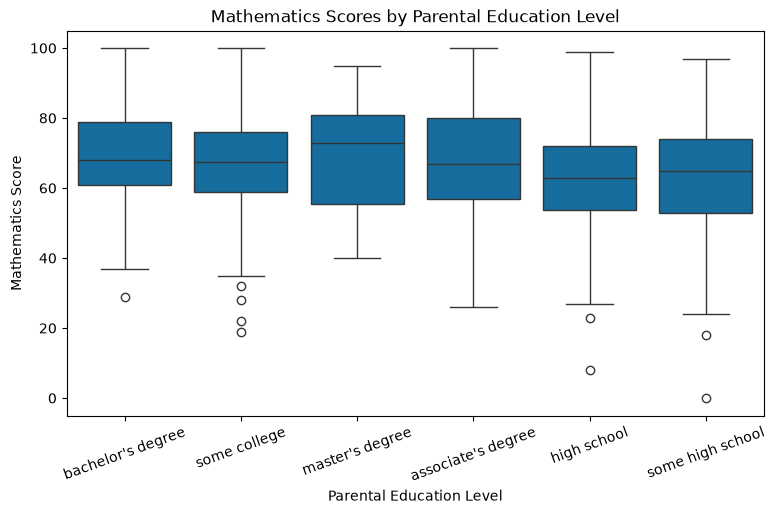

In [70]:
plt.figure(figsize=(9, 5))
sns.boxplot(
    data=df_exams,
      x="parental level of education",
      y="math score",
      color="#0072B2"
)

plt.title("Mathematics Scores by Parental Education Level")
plt.xlabel("Parental Education Level")
plt.ylabel("Mathematics Score")
plt.xticks(rotation=20)
plt.show()

##### Mathematics Scores by Parental Education Level

The boxplot reveals modest differences in mathematics performance across parental education groups. Students whose parents hold master's or bachelor's degree generally exhibit higher median mathematics scores than students whose parents have a high school education or less.

The interquartile ranges (boxes) are broadly similar across groups, suggesting that score variability is reasonably consistent. Although some differences in spread are visible, particularly among the master's degree, and associates's degree, these differences do not appear substantial based on visual inspection alone.

A small number of potential outliers are present, primarily at the lower end of the score distribution. However, these observations appear plausible within the educational context and are not sufficiently numerous to suggest a data quality concern.

Overall, the plot suggests a potential positive relationship between parental educational attainment and student mathematics performance. The observed differences appear moderate rather than dramatic, highlighting the need for formal statistical testing to determine whether the group means differ significantly.

In [73]:
# levene test of homogenity

groups = [
    group["math score"].values
    for _, group in df_exams.groupby("parental level of education")
]

levene_stat, p_value = stats.levene(*groups)

print(f"Levene Statistic: {levene_stat:.4f}")
print(f"P-value: {p_value:.4f}")

Levene Statistic: 0.9333
P-value: 0.4584


### Homogeneity of Variance Assessment

Prior to conducting the ANOVA, Levene's test was used to assess the assumption of homogeneity of variance across parental education groups.

The test produced a statistic of 0.933 and a p-value of 0.458. Since the p-value exceeds the conventional significance level of 0.05, there is insufficient evidence to conclude that the group variances differ significantly.

This result supports the assumption of homogeneity of variance required for a one-way ANOVA. Furthermore, the finding is consistent with the earlier boxplot, which showed that the dispersion of mathematics scores appeared reasonably similar across the parental education categories.

Based on both the visual inspection and Levene's test, the equal variance assumption appears to be satisfied.

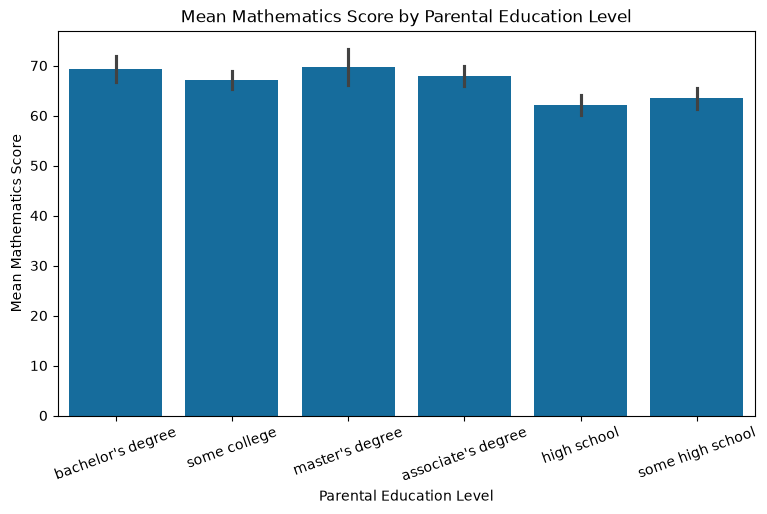

In [82]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=df_exams,
    x="parental level of education",
    y="math score",
    errorbar=("ci", 95),
      color="#0072B2"
)

plt.title("Mean Mathematics Score by Parental Education Level")
plt.xlabel("Parental Education Level")
plt.ylabel("Mean Mathematics Score")

plt.xticks(rotation=20)

plt.show()

##### Mean Mathematics Score by Parental Education Level

The bar chart displays the average mathematics score for each parental education category, along with 95% confidence intervals around the mean estimates. A general positive trend is visible, with students whose parents hold bachelor's, associate's, or master's degrees achieving somewhat higher average mathematics scores than students whose parents have a high school education or less.

Although an ordering of group means is apparent, the differences are not dramatic. The confidence intervals overlap among several groups, particularly within the higher-education categories and within the lower-education categories. This suggests that some observed differences may be attributable to sampling variability rather than large underlying differences in academic performance.

The master's degree group exhibits the highest average mathematics score, while the high school group exhibits the lowest. However, visual inspection alone cannot determine whether these differences are statistically significant. A formal one-way ANOVA will therefore be conducted to determine whether mathematics scores differ significantly across parental education levels.